# Question : How each response is affecting the movement of the macaque? 

In [1]:
!pip install pynwb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 20.1 MB/s eta 0:00:00


In [2]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x133143071452544
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [3]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x133143071631328
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [4]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [7]:
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [9]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [10]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [11]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [12]:
trials = nwbfile.trials

# Print out the column names to see what trial parameters are recorded
print("Available columns in trials table:")
print(trials.colnames)

# View the first 5 rows of the trials table as a pandas DataFrame
import pandas as pd
df_trials = trials.to_dataframe()
print("\nFirst 5 trials:")
print(df_trials.head())

Available columns in trials table:
('start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time', 'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time', 'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur', 'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split')

First 5 trials:
    start_time  stop_time  fix_on_time  fix_time  target_on_time  ready_time  \
id                                                                             
0       0.5160     3.4825       0.5160    0.5500          1.0835      1.7835   
1       3.9995     7.1495       3.9995    4.0335          4.6335      5.2670   
2       7.6660    11.7995       7.6660    7.7000          8.6000      9.5500   
3      12.3165    12.3830      12.3165   12.3505             NaN         NaN   
4      13.9160    17.7160      13.9160   14.0670         14.9335     15.2335   

    set_time  go_time  target_acq_time  reward_time  ...  is_eye  theta  \
id                                

In [13]:
# Check what is inside the processing module, as movement data is often there
print(nwbfile.processing.keys())
# Usually, kinematic data is under 'behavior' or 'position'
# For example:
# print(nwbfile.processing['behavior']['Position'].data[:])

dict_keys([])


In [14]:
# Run this to see the structure of your processing module
if 'behavior' in nwbfile.processing:
    print(nwbfile.processing['behavior'].data_interfaces.keys())
else:
    print("Behavior module not found. Checking top-level...")
    print(nwbfile.acquisition.keys())

Behavior module not found. Checking top-level...
dict_keys([])


In [15]:
# Create a DataFrame of trials
df_trials = nwbfile.trials.to_dataframe()

# Define Reaction Time as the time from 'go_time' to 'target_acq_time'
df_trials['reaction_time'] = df_trials['target_acq_time'] - df_trials['go_time']

# Remove rows where movement/reaction time data might be NaN (incomplete trials)
df_valid = df_trials.dropna(subset=['reaction_time'])

print(df_valid[['go_time', 'target_acq_time', 'reaction_time']].head())

    go_time  target_acq_time  reaction_time
id                                         
0    3.4170           3.4175         0.0005
1    7.0795           7.0800         0.0005
2   11.7715          11.7715         0.0000
4   17.1895          17.1895         0.0000
5   21.4295          21.4300         0.0005


In [16]:
# Create a list to store neural activity per trial
trial_data = []

# Iterate through each valid trial
for idx, row in df_valid.iterrows():
    # Find the indices corresponding to the 'set_time' to 'go_time' window
    start_idx = int(row['set_time'] / 0.02)
    end_idx = int(row['go_time'] / 0.02)
    
    # Extract spike counts for this window (summed across all 54 units)
    # This gives us a single value representing "Total Neural Activity" for this trial
    if start_idx < end_idx:
        activity = np.sum(train_matrix[start_idx:end_idx, :])
        trial_data.append({
            'trial_id': idx,
            'neural_activity': activity,
            'target_duration': row['tp']
        })

df_analysis = pd.DataFrame(trial_data)
print(df_analysis.head())

   trial_id  neural_activity  target_duration
0         0            322.0          850.963
1         1            304.0          930.199
2         2            343.0         1038.650
3         4            415.0         1073.084
4         5            350.0         1046.615


Correlation between neural activity and target duration: 0.872


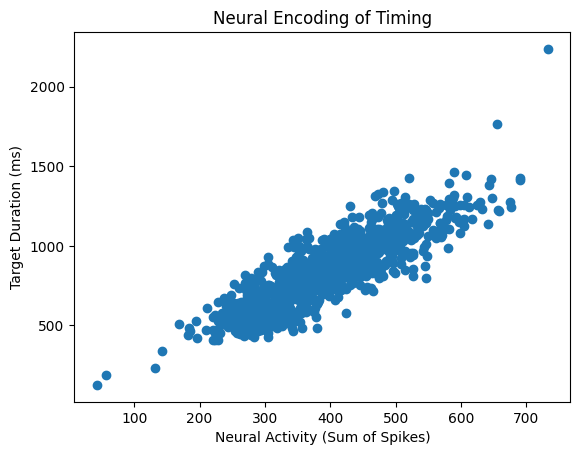

In [17]:
correlation = df_analysis['neural_activity'].corr(df_analysis['target_duration'])
print(f"Correlation between neural activity and target duration: {correlation:.3f}")

# Optional: Plot it to visualize
import matplotlib.pyplot as plt
plt.scatter(df_analysis['neural_activity'], df_analysis['target_duration'])
plt.xlabel('Neural Activity (Sum of Spikes)')
plt.ylabel('Target Duration (ms)')
plt.title('Neural Encoding of Timing')
plt.show()

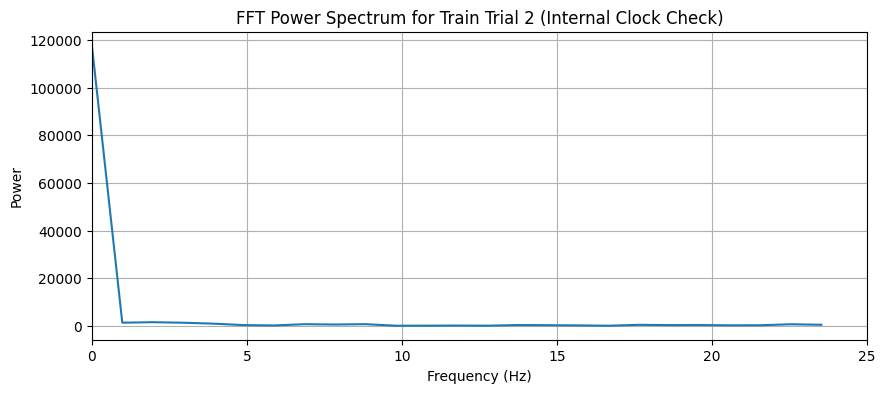

In [18]:
# 1. Select a long trial to ensure enough time points for FFT
# Let's pick a trial with a duration > 1 second (50 bins)
long_trials = df_trials[df_trials['ts'] > 1000]
trial_id = long_trials.index[0] # Pick the first long trial

# 2. Get the indices
start_idx = int(df_trials.loc[trial_id, 'set_time'] / 0.02)
end_idx = int(df_trials.loc[trial_id, 'go_time'] / 0.02)

# 3. Get the population time-series (Summing all units per bin)
# We flatten this to a 1D array representing population activity over time
population_ts = np.sum(train_matrix[start_idx:end_idx, :], axis=1)

# 4. Apply FFT
n = len(population_ts)
fft_values = np.fft.fft(population_ts)
frequencies = np.fft.fftfreq(n, d=0.02) # d is the bin size (0.02s)

# 5. Only look at positive frequencies and the Power Spectrum (Magnitude^2)
positive_freqs = frequencies[:n//2]
power_spectrum = np.abs(fft_values[:n//2])**2

# 6. Plotting
plt.figure(figsize=(10, 4))
plt.plot(positive_freqs, power_spectrum)
plt.title(f'FFT Power Spectrum for Train Trial {trial_id} (Internal Clock Check)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.xlim(0, 25) # Limit to 0-25Hz (Nyquist frequency is 1/(2*0.02) = 25Hz)
plt.grid(True)
plt.show()

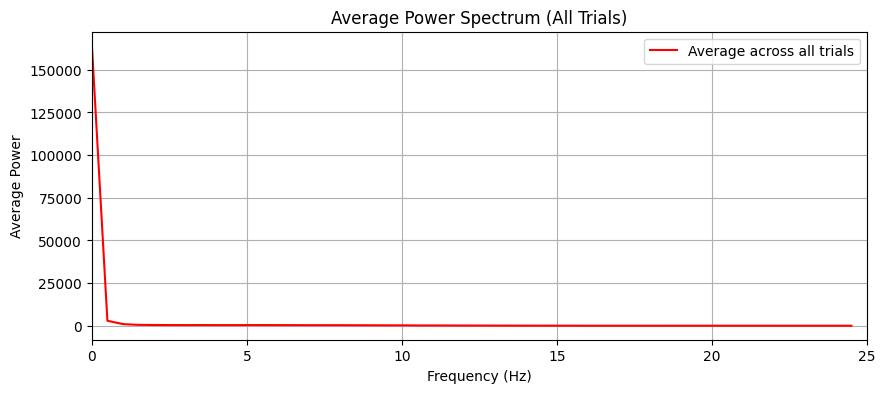

In [19]:
# 1. Initialize to store power spectra from all valid trials
all_power_spectra = []

# 2. Iterate through all trials
for idx in df_valid.index:
    start_idx = int(df_valid.loc[idx, 'set_time'] / 0.02)
    end_idx = int(df_valid.loc[idx, 'go_time'] / 0.02)
    
    # We need a minimum duration
    if (end_idx - start_idx) >= 20: 
        population_ts = np.sum(train_matrix[start_idx:end_idx, :], axis=1)
        
        # Apply FFT
        n = len(population_ts)
        fft_values = np.fft.fft(population_ts)
        power = np.abs(fft_values[:n//2])**2
        
        # FIX: Pad or truncate the power spectrum to a fixed length (e.g., 50)
        fixed_length = 50
        if len(power) >= fixed_length:
            all_power_spectra.append(power[:fixed_length])
        else:
            # Pad with zeros if the trial is too short to reach 50 bins
            padded_power = np.pad(power, (0, fixed_length - len(power)), 'constant')
            all_power_spectra.append(padded_power)

# 3. Calculate the Average (this will now work!)
avg_power = np.nanmean(all_power_spectra, axis=0)
freqs = np.fft.fftfreq(100, d=0.02)[:50]

# 4. Plot
plt.figure(figsize=(10, 4))
plt.plot(freqs, avg_power, color='red', label='Average across all trials')
plt.title('Average Power Spectrum (All Trials)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Average Power')
plt.xlim(0, 25)
plt.grid(True)
plt.legend()
plt.show()

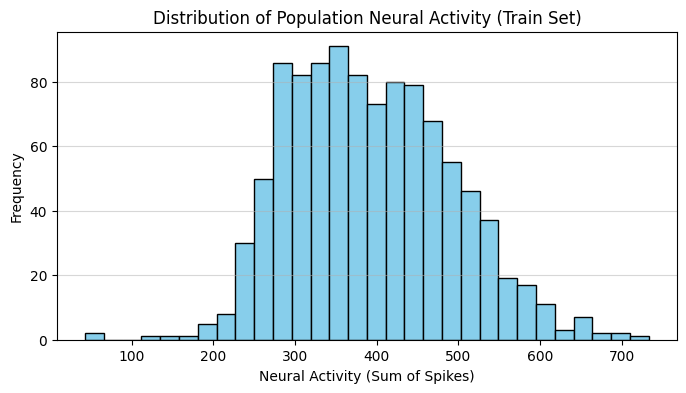

In [21]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(8, 4)) 
plt.hist(df_analysis['neural_activity'], bins=30, color='skyblue', edgecolor='black') 
plt.title('Distribution of Population Neural Activity (Train Set)') 
plt.xlabel('Neural Activity (Sum of Spikes)') 
plt.ylabel('Frequency') 
plt.grid(axis='y', alpha=0.5) 
plt.show()